# Phase 1: Data Processing & Exploratory Data Analysis

This notebook handles the initial data pipeline and exploration stages for the retail demand forecasting project. The objective is to ingest the raw dataset, resolve data quality issues, and uncover baseline demand drivers before moving to time series forecasting.

### Pipeline Objectives
1. **Data Cleaning & Validation:**
   * Standardize data types (specifically datetime casting).
   * Handle missing values and remove duplicate records.
   * Detect and flag anomalies (e.g., negative inventory or pricing errors).
2. **Exploratory Data Analysis (EDA):**
   * Assess high-level sales metrics and temporal trends.
   * Identify operational bottlenecks (stockout vs. overstock frequencies across regions and categories).
   * Analyze external demand drivers, including promotional impact and weather conditions.
3. **Artifact Generation:**
   * Export the processed dataset as `cleaned_retail_data.csv`. This acts as an immutable, clean handoff file for the predictive modeling phase in Notebook 02.

### 1. Initial Data Inspection
First, we load the raw dataset to understand its structure. The goal here is to identify the total number of records, verify the data types assigned to each column, and get a baseline count of any missing values before applying transformations.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

# Reading from our "cloud storage" (Google Drive)
file_path = '/content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis/data/raw/retail_store_inventory.csv'
df = pd.read_csv(file_path)

# 1. Check the dimensions (rows and columns)
print(f"Dataset Shape: {df.shape}\n")

# 2. Check the data types and look for missing values structurally
print("--- Dataset Info ---")
df.info()

# 3. Check exact count of missing values per column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 4. Peek at the first 5 rows to see what the actual data looks like
print("\n--- First 5 Rows ---")
display(df.head())

Dataset Shape: (73100, 15)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: f

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


### 2. Data Type Formatting and Deduplication
The dataset has zero missing values. The immediate priority is converting the `Date` column from a string (`object`) to a proper datetime format, which is a strict requirement for time series forecasting. Following this, we will remove any duplicate rows and inspect the categorical features for inconsistent naming conventions.

In [7]:
# 1. Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Check for and drop exact duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Exact duplicate rows found: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Dataset Shape after dropping duplicates: {df.shape}")

# 3. Check categorical consistency to look for typos or mismatched cases
print("\n--- Categorical Unique Values ---")
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 20)

# 4. Verify the Date conversion
print("\n--- Updated Date Info ---")
print(f"Date dtype: {df['Date'].dtype}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Exact duplicate rows found: 0

--- Categorical Unique Values ---
Category:
['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']
--------------------
Region:
['North' 'South' 'West' 'East']
--------------------
Weather Condition:
['Rainy' 'Sunny' 'Cloudy' 'Snowy']
--------------------
Seasonality:
['Autumn' 'Summer' 'Winter' 'Spring']
--------------------

--- Updated Date Info ---
Date dtype: datetime64[ns]
Date range: 2022-01-01 to 2024-01-01


### 3. Outlier and Logical Check
Before finalizing the dataset, we must ensure the numeric values represent physical reality. We are checking the summary statistics to verify that there are no negative values for inventory, sales, or pricing, and to identify any extreme outliers that could distort the time series forecasting model later.

In [8]:
# 1. Generating summary statistics for numeric columns
print("--- Numeric Summary Statistics ---")
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Competitor Pricing']
display(df[numeric_cols].describe().round(2))

# 2. Check for logical impossibilities (negative inventory, negative sales, zero or negative price)
print("\n --- Logical Validation Checks ---")
negative_inventory = (df['Inventory Level'] < 0).sum()
negative_sales = (df['Units Sold'] < 0).sum()
negative_pricing = (df['Price'] < 0).sum()

print(f"Rows with Negative Inventory: {negative_inventory}")
print(f"Rows with Negative Units Sold: {negative_sales}")
print(f"Rows with Negative Pricing: {negative_pricing}")

--- Numeric Summary Statistics ---


,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Competitor Pricing
count,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00
mean,274.47,136.46,110.00,141.49,55.14,55.15
std,129.95,108.92,52.28,109.25,26.02,26.19
min,50.00,0.00,20.00,-9.99,10.00,5.03
25%,162.00,49.00,65.00,53.67,32.65,32.68
50%,273.00,107.00,110.00,113.02,55.05,55.01
75%,387.00,203.00,155.00,208.05,77.86,77.82
max,500.00,499.00,200.00,518.55,100.00,104.94



 --- Logical Validation Checks ---
Rows with Negative Inventory: 0
Rows with Negative Units Sold: 0
Rows with Negative Pricing: 0


### 4. Correcting Anomalies and Exporting
The summary statistics revealed a minimum `Demand Forecast` value of -9.99. Since negative demand is a logical impossibility, we will cap these values at 0. Finally, we will export this validated DataFrame as a CSV, completing the data cleaning pipeline.

In [9]:
# 1. Fixing the negative demand forecast values by capping them at 0
df['Demand Forecast'] = df['Demand Forecast'].clip(lower=0)
print(f"Minimum Demand Forecast after fix: {df['Demand Forecast'].min()}")

# 2. Exporting the clean dataset
export_path = 'cleaned_retail_data.csv'
df.to_csv(export_path, index=False)
print(f"Cleaned dataset exported to: {export_path}")

Minimum Demand Forecast after fix: 0.0
Cleaned dataset exported to: cleaned_retail_data.csv


## Phase 2: Exploratory Data Analysis (OPTD)


### O - Overview
The objective of this overview is to establish baseline KPIs and visualize the macro-level sales trend across the entire dataset. I need to determine if overall demand is flat, growing, or seasonal before digging into specific pain points like stockouts.

--- Baseline KPIs ---

Average Units Sold (per record): 136.46
Average Inventory Level (per record): 274.47


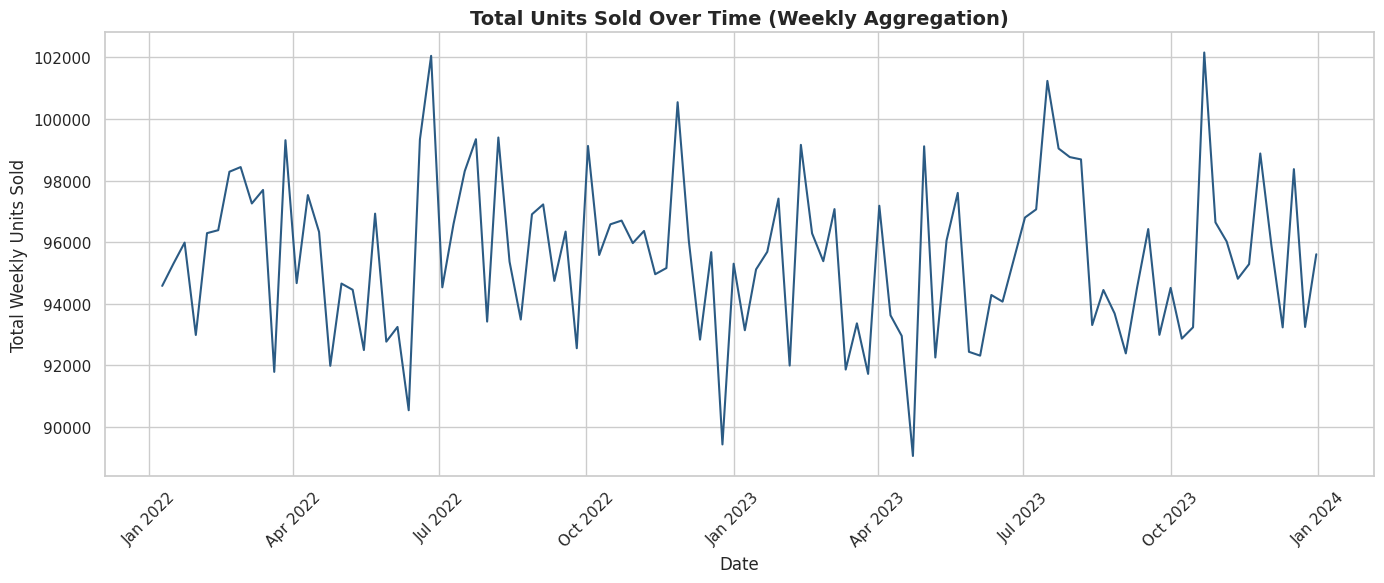

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Calculating baseline KPIs
avg_daily_sales = df['Units Sold'].mean()
avg_inventory = df['Inventory Level'].mean()

print("--- Baseline KPIs ---\n")
print(f"Average Units Sold (per record): {avg_daily_sales:.2f}")
print(f"Average Inventory Level (per record): {avg_inventory:.2f}")


# 2. Visualize Trend
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()
daily_sales.set_index('Date', inplace=True)
weekly_sales = daily_sales.resample('W').sum().reset_index()

weekly_sales = weekly_sales.iloc[1:-1]

# 3. Plotting
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=weekly_sales, x='Date', y='Units Sold', color='#2b5b84', ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.title('Total Units Sold Over Time (Weekly Aggregation)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Weekly Units Sold', fontsize=12)
plt.tight_layout()
plt.show()



### P - Pain Points
Initial analysis using a global inventory percentile threshold showed stockout risk clustered tightly around 5% across all Category × Region combinations. To rule out this being a threshold artifact, the analysis was repeated using a category-specific threshold (5th percentile of inventory within each category, accounting for different categories having different normal stock levels). The result was consistent — stockout risk rate remains within a narrow 5.1%-5.8% band across all combinations. This suggests stockout risk is not concentrated in specific categories or regions, but is instead a systemic, evenly-distributed pattern across the business — possibly pointing to a uniform inventory/replenishment policy rather than a localized operational problem.


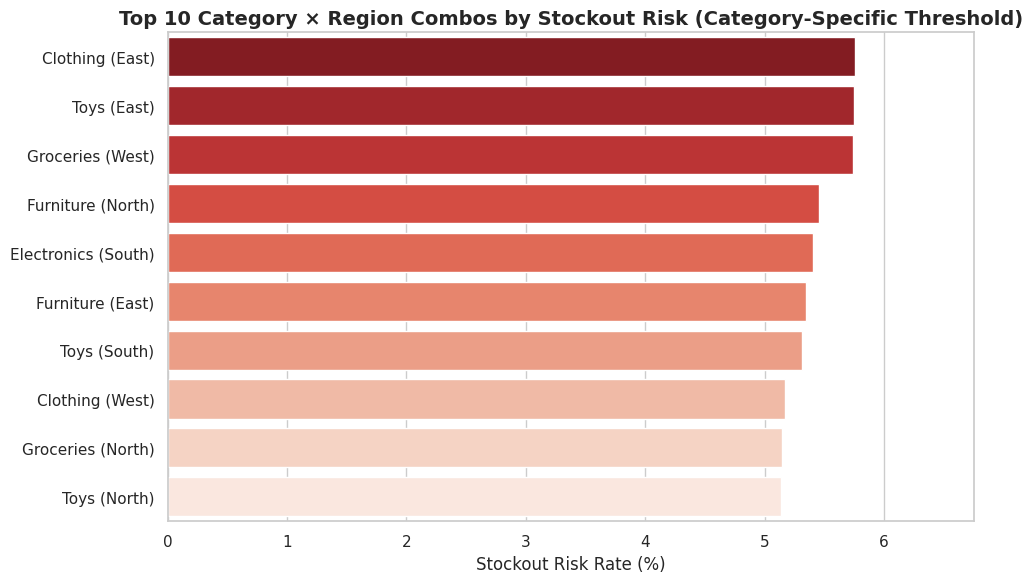

In [27]:
# 1. Calculate category-specific thresholds and assign directly to the main dataframe
df['Low_Stock_Threshold'] = df.groupby('Category')['Inventory Level'].transform(lambda x: x.quantile(0.05))

# 2. Flag the days where inventory drops to or below the category's specific threshold
df['Is_Low_Stock'] = df['Inventory Level'] <= df['Low_Stock_Threshold']

# 3. Group by Category and Region to calculate the true rate
risk_summary = df.groupby(['Category', 'Region'])['Is_Low_Stock'].agg(['sum', 'count']).reset_index()
risk_summary['Stockout Risk Rate (%)'] = (risk_summary['sum'] / risk_summary['count']) * 100
risk_summary['Category_Region'] = risk_summary['Category'] + " (" + risk_summary['Region'] + ")"

# 4. Sort and visualize the top 10
top_10_risk = risk_summary.sort_values(by='Stockout Risk Rate (%)', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_risk, x='Stockout Risk Rate (%)', y='Category_Region', palette='Reds_r', hue='Category_Region', legend=False)

plt.title('Top 10 Category × Region Combos by Stockout Risk (Category-Specific Threshold)', fontsize=14, fontweight='bold')
plt.xlabel('Stockout Risk Rate (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, top_10_risk['Stockout Risk Rate (%)'].max() + 1)
plt.tight_layout()
plt.show()

### P - Pain Points: Overstock Risk
Having established that stockout risk is uniform, I am now checking for overstock (dead stock) combinations.

Applying the methodological lesson from the stockout analysis, I am using category-specific thresholds rather than global ones. A day is flagged as "Overstock" if the `Inventory Level` is in the top 25% for its category, while `Units Sold` simultaneously falls into the bottom 25% for its category. I will then calculate the frequency of these days as a percentage rate per Category × Region.

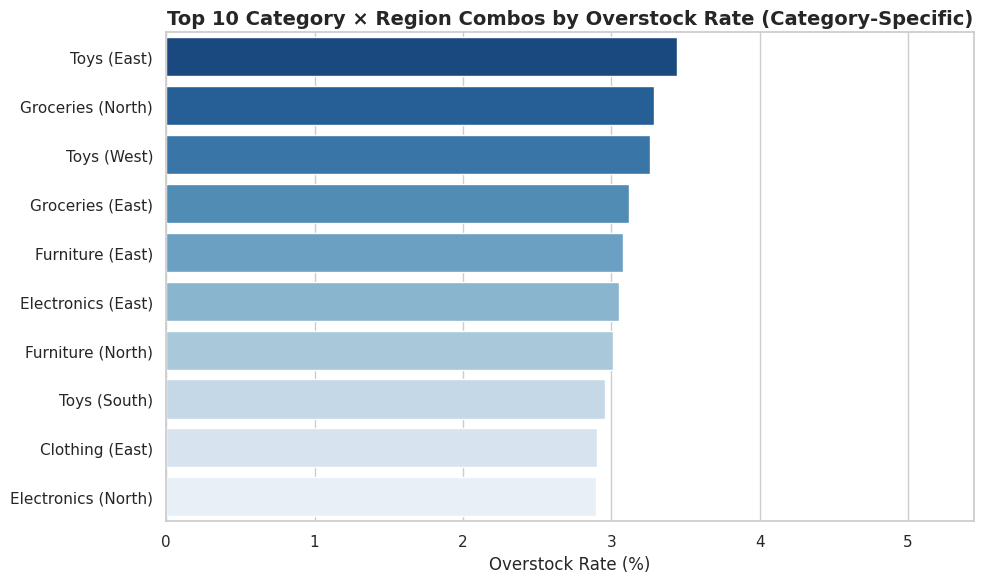

In [29]:
# 1. Calculating specific thresholds for high inventory and low sales
df['High_Inv_Threshold'] = df.groupby('Category')['Inventory Level'].transform(lambda x: x.quantile(0.75))
df['Low_Sales_Threshold'] = df.groupby('Category')['Units Sold'].transform(lambda x: x.quantile(0.25))

# 2. Flagging the overstack days
df['Is_Overstock'] = (df['Inventory Level'] >= df['High_Inv_Threshold']) & (df['Units Sold'] <= df['Low_Sales_Threshold'])

# 3. Groupby Category and Region to calculate overstack rate
overstock_summary = df.groupby(['Category', 'Region'])['Is_Overstock'].agg(['sum', 'count']).reset_index()
overstock_summary['Overstock Rate (%)'] = (overstock_summary['sum'] / overstock_summary['count']) * 100
overstock_summary['Category_Region'] = overstock_summary['Category'] + " (" + overstock_summary['Region'] + ")"

# 4. Sort and isolate the top 10
top_10_overstock = overstock_summary.sort_values(by='Overstock Rate (%)', ascending=False).head(10)

# 5. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_overstock, x='Overstock Rate (%)', y='Category_Region', palette='Blues_r', hue='Category_Region', legend=False)

plt.title('Top 10 Category × Region Combos by Overstock Rate (Category-Specific)', fontsize=14, fontweight='bold')
plt.xlabel('Overstock Rate (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, top_10_overstock['Overstock Rate (%)'].max() + 2)
plt.tight_layout()
plt.show()

### P - Pain Points: Underperforming Stores
The final pain point investigation focuses on store-level performance. Instead of plotting every store in the dataset, I am calculating the average daily units sold per store and isolating the bottom 10. This highlights specific locations that are consistently underperforming and dragging down overall sales metrics.

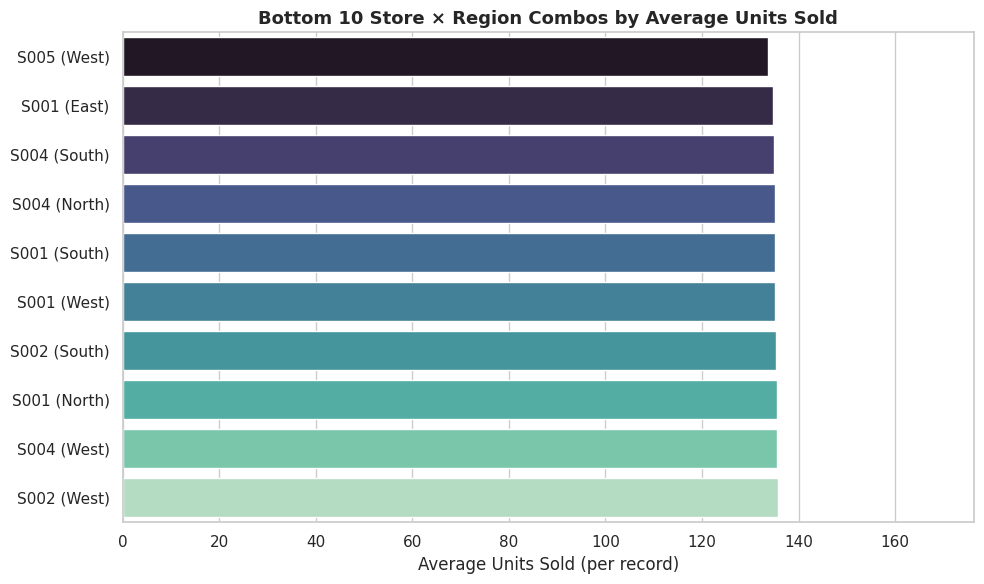

In [34]:
# 1. Calculate average units sold per Store ID x Region
store_performance = df.groupby(['Store ID', 'Region'])['Units Sold'].mean().reset_index()

# 2. Sort ascending to get the lowest performers at the top of our list
bottom_10_stores = store_performance.sort_values(by='Units Sold', ascending=True).head(10)

# Combine Store ID and Region for a clean chart label
bottom_10_stores['Store_Label'] = bottom_10_stores['Store ID'] + " (" + bottom_10_stores['Region'] + ")"

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_10_stores, x='Units Sold', y='Store_Label', palette='mako', hue='Store_Label', legend=False)

plt.title('Bottom 10 Store × Region Combos by Average Units Sold', fontsize=13, fontweight='bold')
plt.xlabel('Average Units Sold (per record)', fontsize=12)
plt.ylabel('')
plt.xlim(0, bottom_10_stores['Units Sold'].max() * 1.3)
plt.tight_layout()
plt.show()